# Fine-tuning Helsinki-NLP/opus-mt-en-vi cho domain Triết học

**Chiến lược:** Full fine-tuning · **Split:** Topic-based 33/2/2 · **Colab:** T4 16GB fp16

| Thành phần | Giá trị |
|---|---|
| Base model | `Helsinki-NLP/opus-mt-en-vi` (~74M params) |
| Max length | 256 / 384 (source / target) |
| Batch size | 32 |
| Learning rate | 3e-5 + cosine + warmup 10% |
| Epochs | 15 + early stopping (patience=3) |
| Metrics | BLEU + chrF++ |
| Checkpoint | Google Drive |

## 1. Cài đặt môi trường

In [1]:
# Kiểm tra GPU
!nvidia-smi
!pip install -q transformers datasets evaluate sacrebleu sentencepiece accelerate

Sat May 16 19:14:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Kết nối Google Drive & Import

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from transformers import (
    MarianMTModel, MarianTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
from datasets import Dataset, DatasetDict
import evaluate

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch  : {torch.__version__}')
print(f'GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')

PyTorch  : 2.10.0+cu128
GPU      : Tesla T4
VRAM     : 15.6 GB


## 3. Cấu hình

In [4]:
# ── Đường dẫn ─────────────────────────────────────────────────────────────────
# Đặt dataset.jsonl trong MyDrive/PhilosophyMT/ trước khi chạy
DRIVE_ROOT    = Path('/content/drive/MyDrive/PhilosophyMT')
DATASET_PATH  = DRIVE_ROOT / 'dataset.jsonl'
CHECKPOINT_DIR = DRIVE_ROOT / 'checkpoints'
FINAL_MODEL_DIR = DRIVE_ROOT / 'model_final'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME = 'Helsinki-NLP/opus-mt-en-vi'

# ── Sequence length ───────────────────────────────────────────────────────────
MAX_SOURCE_LEN = 256   # EN: mean ~150 token, 256 bao phủ dư
MAX_TARGET_LEN = 384   # VI: dài hơn EN ~1.5×, 384 bao phủ ~99% mẫu

# ── Split ─────────────────────────────────────────────────────────────────────
N_TRAIN_TOPICS = 33
N_VAL_TOPICS   = 2
N_TEST_TOPICS  = 2     # tổng: 37 topics

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE          = 32
LEARNING_RATE       = 3e-5
NUM_EPOCHS          = 15
WARMUP_RATIO        = 0.1
WEIGHT_DECAY        = 0.01
EARLY_STOP_PATIENCE = 3
NUM_BEAMS           = 4

print('Cấu hình đã sẵn sàng.')

Cấu hình đã sẵn sàng.


## 4. Tải & kiểm tra dữ liệu

In [5]:
records = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

# Chỉ lấy các record đã dịch
df = df[df['vi'].str.strip().str.len() > 0].reset_index(drop=True)

print(f'Records đã dịch : {len(df):,}')
print(f'Số topics       : {df["topic"].nunique()}')
print(f'EN words — mean: {df["en"].str.split().str.len().mean():.0f}, '
      f'median: {df["en"].str.split().str.len().median():.0f}, '
      f'max: {df["en"].str.split().str.len().max()}')
df[['en','vi']].head(2)

Records đã dịch : 4,707
Số topics       : 37
EN words — mean: 113, median: 115, max: 247


,en,vi
0,Benedict de Spinoza was among the most import...,Benedict de Spinoza là một trong những triết g...
1,"Among philosophers, Spinoza is best known for ...","Trong giới triết gia, Spinoza được biết đến nh..."


## 5. Chia tập theo topic (Topic-based Split)

> **Lý do dùng topic-based split thay vì random:**  
> Dataset có overlap 1 câu giữa các chunk liền kề cùng topic. Split ngẫu nhiên sẽ gây **data leakage** (chunk i và i+1 share câu, lại rơi vào train và test).  
> Split theo topic đảm bảo model được đánh giá trên **bài viết hoàn toàn chưa thấy**.

In [6]:
all_topics = df['topic'].unique().tolist()
random.shuffle(all_topics)   # SEED=42 đảm bảo reproducible

train_topics = all_topics[:N_TRAIN_TOPICS]
val_topics   = all_topics[N_TRAIN_TOPICS : N_TRAIN_TOPICS + N_VAL_TOPICS]
test_topics  = all_topics[N_TRAIN_TOPICS + N_VAL_TOPICS :]

train_df = df[df['topic'].isin(train_topics)].reset_index(drop=True)
val_df   = df[df['topic'].isin(val_topics)].reset_index(drop=True)
test_df  = df[df['topic'].isin(test_topics)].reset_index(drop=True)

print(f'Train : {len(train_df):,} records — {len(train_topics)} topics')
print(f'Val   : {len(val_df):,} records — {len(val_topics)} topics')
print(f'Test  : {len(test_df):,} records — {len(test_topics)} topics')
print(f'\nVal  topics : {val_topics}')
print(f'Test topics : {test_topics}')

Train : 4,106 records — 33 topics
Val   : 297 records — 2 topics
Test  : 304 records — 2 topics

Val  topics : ['David Hume (1711—1776)', 'David Hume: Imagination']
Test topics : ['Benedict de Spinoza: Epistemology', 'Immanuel Kant']


## 6. Tokenizer & Tiền xử lý

In [7]:
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)

print(f'Vocab size     : {tokenizer.vocab_size:,}')
print(f'Max model len  : {tokenizer.model_max_length}')

# Kiểm tra độ dài token thực tế trên dataset
sample_en_lengths = [len(tokenizer(t)['input_ids'])
                     for t in df['en'].sample(500, random_state=42)]
sample_vi_lengths = [len(tokenizer(t)['input_ids'])
                     for t in df['vi'].sample(500, random_state=42)]

print(f'\nToken length EN — mean: {np.mean(sample_en_lengths):.0f}, '
      f'p95: {np.percentile(sample_en_lengths, 95):.0f}, '
      f'max: {max(sample_en_lengths)}')
print(f'Token length VI — mean: {np.mean(sample_vi_lengths):.0f}, '
      f'p95: {np.percentile(sample_vi_lengths, 95):.0f}, '
      f'max: {max(sample_vi_lengths)}')
print(f'\n→ MAX_SOURCE_LEN={MAX_SOURCE_LEN} (EN), MAX_TARGET_LEN={MAX_TARGET_LEN} (VI) '
      f'— target dài hơn vì VI/EN ratio ~1.5×.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/809k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/756k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Vocab size     : 53,685
Max model len  : 512


Token indices sequence length is longer than the specified maximum sequence length for this model (611 > 512). Running this sequence through the model will result in indexing errors



Token length EN — mean: 151, p95: 212, max: 346
Token length VI — mean: 447, p95: 614, max: 875

→ MAX_SOURCE_LEN=256 (EN), MAX_TARGET_LEN=384 (VI) — target dài hơn vì VI/EN ratio ~1.5×.


In [9]:
def preprocess_function(examples):
    """
    Tokenize cặp EN→VI.
    - padding='max_length': pad đồng đều trong batch → DataCollator không cần pad thêm
    - Labels: thay pad_token_id bằng -100 để loss không tính trên padding
    """
    model_inputs = tokenizer(
        examples['en'],
        max_length=MAX_SOURCE_LEN,
        truncation=True,
        padding='max_length',
    )
    targets = tokenizer(
        text_target=examples['vi'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length',
    )

    labels = [
        [-100 if token == tokenizer.pad_token_id else token
         for token in label]
        for label in targets['input_ids']
    ]
    model_inputs['labels'] = labels
    return model_inputs


# Chuyển sang HuggingFace Dataset
raw_datasets = DatasetDict({
    'train' : Dataset.from_pandas(train_df[['en','vi']]),
    'val'   : Dataset.from_pandas(val_df[['en','vi']]),
    'test'  : Dataset.from_pandas(test_df[['en','vi']]),
})

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    batch_size=256,
    remove_columns=['en','vi'],
    desc='Tokenizing',
)

print(tokenized_datasets)
print(f'\nSample input_ids shape : {len(tokenized_datasets["train"][0]["input_ids"])}')
print(f'Sample labels shape    : {len(tokenized_datasets["train"][0]["labels"])}')

Tokenizing:   0%|          | 0/4106 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/297 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/304 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4106
    })
    val: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 297
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 304
    })
})

Sample input_ids shape : 256
Sample labels shape    : 384


## 7. Khởi tạo Model

In [10]:
model = MarianMTModel.from_pretrained(MODEL_NAME)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Tổng params     : {total_params:,}')
print(f'Trainable params: {trainable_params:,}  ({trainable_params/total_params*100:.1f}%)')
print(f'Model config    : d_model={model.config.d_model}, '
      f'encoder_layers={model.config.encoder_layers}, '
      f'decoder_layers={model.config.decoder_layers}')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/289M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/289M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Tổng params     : 127,122,944
Trainable params: 127,122,944  (100.0%)
Model config    : d_model=512, encoder_layers=6, decoder_layers=6


## 8. Metrics — BLEU & chrF++

In [11]:
bleu_metric = evaluate.load('sacrebleu')
chrf_metric = evaluate.load('chrf')

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Thay -100 (padding mask) bằng pad_token_id để decode được
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,   skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # BLEU: references phải là list of list
    bleu = bleu_metric.compute(
        predictions=decoded_preds,
        references=[[l] for l in decoded_labels],
    )

    # chrF++: word_order=2 → chrF++
    chrf = chrf_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        word_order=2,
    )

    return {
        'bleu' : round(bleu['score'], 4),
        'chrf' : round(chrf['score'], 4),
    }

print('Metrics đã sẵn sàng: BLEU (sacrebleu) + chrF++')

Metrics đã sẵn sàng: BLEU (sacrebleu) + chrF++


## 9. Cấu hình Training

In [13]:
warmup_steps = int(
    (len(tokenized_datasets["train"]) // BATCH_SIZE) * NUM_EPOCHS * WARMUP_RATIO
)

training_args = Seq2SeqTrainingArguments(
    output_dir=str(CHECKPOINT_DIR),

    # ── Epochs & batch ────────────────────────────────────────────────────
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    # ── Optimizer & scheduler ─────────────────────────────────────────────
    learning_rate=LEARNING_RATE,
    lr_scheduler_type='cosine',
    warmup_steps=warmup_steps,
    weight_decay=WEIGHT_DECAY,

    # ── Precision ─────────────────────────────────────────────────────────
    fp16=True,

    # ── Generation (dùng khi eval) ────────────────────────────────────────
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=NUM_BEAMS,

    # ── Eval & Save ───────────────────────────────────────────────────────
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='bleu',
    greater_is_better=True,

    # ── Logging ───────────────────────────────────────────────────────────
    logging_steps=50,
    report_to='none',

    # ── Misc ──────────────────────────────────────────────────────────────
    seed=SEED,
    dataloader_num_workers=2,
    group_by_length=True,
)

# Data collator: padding động trong batch
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['val'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)
    ],
)

print('Trainer đã sẵn sàng.')
print(f'Steps/epoch     : {len(tokenized_datasets["train"]) // BATCH_SIZE}')
print(f'Total steps     : {len(tokenized_datasets["train"]) // BATCH_SIZE * NUM_EPOCHS}')
print(f'Warmup steps    : {warmup_steps}')

Trainer đã sẵn sàng.
Steps/epoch     : 128
Total steps     : 1920
Warmup steps    : 192


## 10. Huấn luyện

> **Lưu ý Colab:** Nếu session bị ngắt, chạy lại cell này với `resume_from_checkpoint=True` để tiếp tục từ checkpoint cuối.

In [14]:
# Đặt resume=True nếu muốn tiếp tục từ checkpoint cũ
RESUME = False

train_result = trainer.train(
    resume_from_checkpoint=RESUME
)

print('\n=== Kết quả Training ===')
print(f'Train loss cuối : {train_result.training_loss:.4f}')
print(f'Runtime         : {train_result.metrics["train_runtime"]/60:.1f} phút')
print(f'Samples/second  : {train_result.metrics["train_samples_per_second"]:.1f}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,2.673592,2.038548,31.615200,51.358500
2,2.008812,1.660809,37.550500,56.498400
3,1.756554,1.471522,40.416500,58.839600
4,1.507403,1.373478,42.042400,60.172100
5,1.404054,1.305753,43.107500,60.936300
6,1.278399,1.260516,44.455600,61.924900
7,1.211734,1.220864,44.716000,62.161600
8,1.133575,1.215611,45.725500,62.969900
9,1.090294,1.187560,46.026600,63.262700
10,1.063697,1.169318,46.287200,63.389100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].



=== Kết quả Training ===
Train loss cuối : 1.3660
Runtime         : 39.8 phút
Samples/second  : 25.8


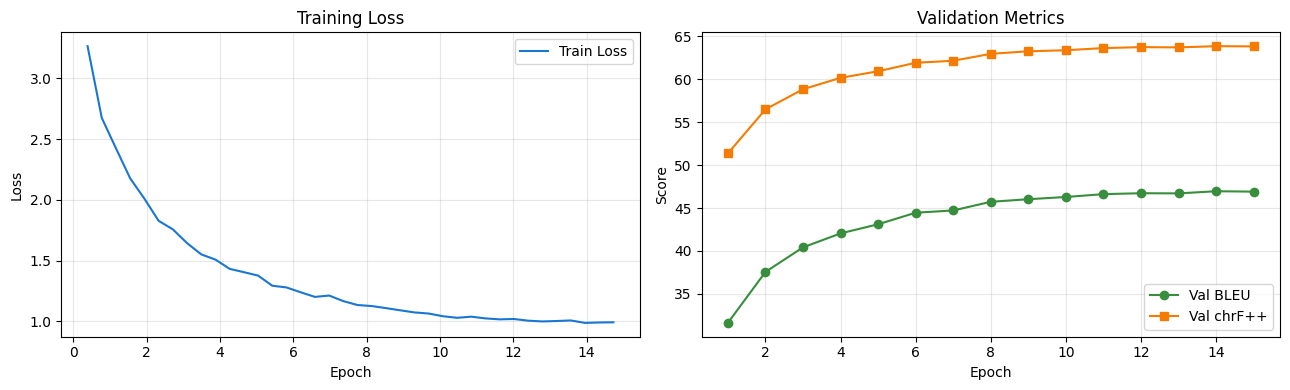

Learning curve đã lưu vào Drive.


In [15]:
# Vẽ learning curve
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_loss = [(h['epoch'], h['loss'])       for h in history if 'loss'      in h and 'eval_loss' not in h]
eval_bleu  = [(h['epoch'], h['eval_bleu'])  for h in history if 'eval_bleu' in h]
eval_chrf  = [(h['epoch'], h['eval_chrf'])  for h in history if 'eval_chrf' in h]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if train_loss:
    ep, loss = zip(*train_loss)
    axes[0].plot(ep, loss, label='Train Loss', color='#1976D2')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if eval_bleu:
    ep, bleu = zip(*eval_bleu)
    axes[1].plot(ep, bleu, label='Val BLEU',  color='#388E3C', marker='o')
if eval_chrf:
    ep, chrf = zip(*eval_chrf)
    axes[1].plot(ep, chrf, label='Val chrF++', color='#F57C00', marker='s')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(DRIVE_ROOT / 'learning_curve.png'), dpi=120)
plt.show()
print('Learning curve đã lưu vào Drive.')

## 11. Đánh giá trên Test Set

In [16]:
# Eval trên Val (tham khảo)
val_metrics = trainer.evaluate(tokenized_datasets['val'])
print('Val  :', {k: round(v, 4) for k, v in val_metrics.items() if 'bleu' in k or 'chrf' in k or 'loss' in k})

# Eval trên Test (kết quả chính thức)
test_metrics = trainer.evaluate(tokenized_datasets['test'])
print('Test :', {k: round(v, 4) for k, v in test_metrics.items() if 'bleu' in k or 'chrf' in k or 'loss' in k})

# Lưu metrics ra file
all_metrics = {'val': val_metrics, 'test': test_metrics}
with open(DRIVE_ROOT / 'eval_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print('\nMetrics đã lưu → eval_metrics.json')

Val  : {'eval_loss': 1.1552, 'eval_bleu': 46.9509, 'eval_chrf': 63.8608}
Test : {'eval_loss': 1.0962, 'eval_bleu': 47.2405, 'eval_chrf': 64.9578}

Metrics đã lưu → eval_metrics.json


In [17]:
# So sánh baseline (opus-mt-en-vi gốc) vs fine-tuned trên test set
print('=== So sánh Baseline vs Fine-tuned ===')
baseline_model = MarianMTModel.from_pretrained(MODEL_NAME).to('cuda' if torch.cuda.is_available() else 'cpu')
baseline_model.eval()

def translate_batch(mdl, texts, src_tokenizer, num_beams=4):
    device = next(mdl.parameters()).device
    inputs = src_tokenizer(
        texts, return_tensors='pt',
        padding=True, truncation=True,
        max_length=MAX_SOURCE_LEN
    ).to(device)
    with torch.no_grad():
        outputs = mdl.generate(**inputs, num_beams=num_beams, max_new_tokens=MAX_TARGET_LEN)
    return src_tokenizer.batch_decode(outputs, skip_special_tokens=True)

test_en  = test_df['en'].tolist()
test_vi  = test_df['vi'].tolist()

# Fine-tuned predictions (dùng best model đã load)
ft_preds = []
CHUNK = 32
for i in range(0, len(test_en), CHUNK):
    ft_preds.extend(translate_batch(trainer.model, test_en[i:i+CHUNK], tokenizer))

# Baseline predictions
bl_preds = []
for i in range(0, len(test_en), CHUNK):
    bl_preds.extend(translate_batch(baseline_model, test_en[i:i+CHUNK], tokenizer))

refs = [[v] for v in test_vi]

bl_bleu = bleu_metric.compute(predictions=bl_preds, references=refs)['score']
ft_bleu = bleu_metric.compute(predictions=ft_preds, references=refs)['score']
bl_chrf = chrf_metric.compute(predictions=bl_preds, references=test_vi, word_order=2)['score']
ft_chrf = chrf_metric.compute(predictions=ft_preds, references=test_vi, word_order=2)['score']

print(f"{'Model':<20} {'BLEU':>8} {'chrF++':>8}")
print('-' * 38)
print(f"{'Baseline (gốc)':<20} {bl_bleu:>8.2f} {bl_chrf:>8.2f}")
print(f"{'Fine-tuned':<20} {ft_bleu:>8.2f} {ft_chrf:>8.2f}")
print(f"{'Δ':<20} {ft_bleu-bl_bleu:>+8.2f} {ft_chrf-bl_chrf:>+8.2f}")

=== So sánh Baseline vs Fine-tuned ===


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model                    BLEU   chrF++
--------------------------------------
Baseline (gốc)          11.67    31.15
Fine-tuned              47.16    64.92
Δ                      +35.50   +33.77


## 12. Demo Inference

In [18]:
def translate(text: str, mdl=None, num_beams: int = 4) -> str:
    """Dịch một đoạn văn tiếng Anh sang tiếng Việt."""
    if mdl is None:
        mdl = trainer.model
    device = next(mdl.parameters()).device
    mdl.eval()
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_SOURCE_LEN
    ).to(device)
    with torch.no_grad():
        output = mdl.generate(**inputs, num_beams=num_beams, max_new_tokens=MAX_TARGET_LEN)
    return tokenizer.decode(output[0], skip_special_tokens=True)


# Lấy 3 mẫu từ test set
samples = test_df.sample(3, random_state=7)

for _, row in samples.iterrows():
    print('=' * 70)
    print(f"Topic   : {row['topic']}")
    print(f"\nEN      : {row['en'][:300]}")
    print(f"\nVI (ref): {row['vi'][:300]}")
    print(f"\nBaseline: {translate(row['en'], baseline_model)[:300]}")
    print(f"\nFT      : {translate(row['en'])[:300]}")
    print()

Topic   : Immanuel Kant

EN      : Kant’s first purely philosophical work was the New Elucidation of the First Principles of Metaphysical Cognition (1755). The first parts of this long essay present criticisms and revisions of the Wolffian understanding of the basic principles of metaphysics, especially the Principles of Identity ( w

VI (ref): Tác phẩm thuần triết học đầu tiên của Kant là Sự soi sáng mới về những nguyên lý đầu tiên của nhận thức siêu hình học (1755). Những phần đầu của tiểu luận dài này trình bày các phê phán và điều chỉnh đối với cách hiểu kiểu Wolff về các nguyên lý cơ bản của siêu hình học, đặc biệt là Nguyên lý Đồng n

Baseline: Những phần đầu tiên của sự chỉ trích dài hiện diện và không có gì là) và của sự hiểu biết về các nguyên tắc siêu nhiên (không có lý do chính xác), đặc biệt là các nguyên tắc cuối cùng (bất cứ điều gì là, và bất cứ điều gì không, không có) của định nghĩa (không có gì có thể là) và không có gì cả), và

FT      : Tác phẩm đầu tiên thuần túy t

## 13. Lưu Model cuối vào Google Drive

In [19]:
# Lưu model + tokenizer
trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

# Lưu config training để tái hiện
config_to_save = {
    'base_model'        : MODEL_NAME,
    'max_source_length' : MAX_SOURCE_LEN,
    'max_target_length' : MAX_TARGET_LEN,
    'batch_size'        : BATCH_SIZE,
    'learning_rate'     : LEARNING_RATE,
    'num_epochs'        : NUM_EPOCHS,
    'warmup_ratio'      : WARMUP_RATIO,
    'weight_decay'      : WEIGHT_DECAY,
    'num_beams'         : NUM_BEAMS,
    'train_topics'      : train_topics,
    'val_topics'        : val_topics,
    'test_topics'       : test_topics,
    'test_bleu'         : round(ft_bleu, 4),
    'test_chrf'         : round(ft_chrf, 4),
    'baseline_bleu'     : round(bl_bleu, 4),
    'baseline_chrf'     : round(bl_chrf, 4),
}
with open(FINAL_MODEL_DIR / 'training_config.json', 'w') as f:
    json.dump(config_to_save, f, indent=2, ensure_ascii=False)

print(f'Model đã lưu tại: {FINAL_MODEL_DIR}')
print('Files:', [p.name for p in FINAL_MODEL_DIR.iterdir()])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model đã lưu tại: /content/drive/MyDrive/PhilosophyMT/model_final
Files: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'vocab.json', 'source.spm', 'target.spm', 'training_args.bin', 'training_config.json']


## 14. Tải lại Model (khi cần dùng sau)

```python
from transformers import MarianMTModel, MarianTokenizer

FINAL_MODEL_DIR = '/content/drive/MyDrive/PhilosophyMT/model_final'
tokenizer = MarianTokenizer.from_pretrained(FINAL_MODEL_DIR)
model     = MarianMTModel.from_pretrained(FINAL_MODEL_DIR)
model.eval()
```